Example notebook contains of four parts: 
- modeling 6P excitation & gauss
- error budget for CZ
- 5P & flattop field
- 5P & two gausses

In [1]:
using NeutralAtoms


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


**1)** Gaussian field and 6P excitation 

Load config file for modeling and set 1 sample at low temperature for calibration to evaluate global RZ angle after CZ.

In [2]:
include("../conf/configs_gen.jl")
_, cfg_CZ = get_6P_config();
cfg_CZ.n_samples = 1;
cfg_CZ.atom_params[2] = 0.1; #temperature  #cfg_CZ.error_options["z_motion"] = false; #true #cfg_CZ.error_options["spontaneous_decay_intermediate"] = false ; 
cfg_CZ.error_options = Dict("laser_noise" => false,"spontaneous_decay_intermediate" => false,
                             "spontaneous_decay_rydberg" => false, "atom_motion" => false,
                             "free_motion" => false,"xy_motion" => false,"z_motion" => false,"Doppler" => false, "blockade"=>false);

In [3]:
ϕ_cal = CZ_caliration(cfg_CZ) 

Δ = 0.37737, ξ = 3.982
Ampls difference: [0.0, -0.001502843921808994, -0.001502843921808994, -0.0008750629425490764]
Phase on state 01: -1.86604381051118, on state 10: -1.86604381051118
avg ϕ_RZ = 1.86604381051118; phase on |11> = 3.0633426735310167; err_norm = 0.00229843748230382


1.86604381051118

This command run the same as CZ simulation and calculation of fidelity of initial state after ideal CZ and RZ rotation for different angles

In [4]:
ϕ_list0, F_list0, ϕ_Phi_plus, p_pr = PhiPlus_fidelity_osc(cfg_CZ); 
println(ϕ_Phi_plus)

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:34<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:34<Inf:Inf, InfGs/it]


1.9052


The only source of mistake is presence of intermediate state, some population will remain there. Other error sources were not included in that modeling.

In [5]:
println(maximum(F_list0), " ", p_pr, " ", ϕ_cal)
println("Calibration angle is ", cfg_CZ.ϕ_RZ)

0.9957413084421369 0.003194359585827875 1.86604381051118
Calibration angle is 1.9053


Maximum fidelity angle differs from value calculated by Lukin's group due to presence of intermediate state, it's detuning and other experimental factors. Let's see temperature dependence:

In [ ]:
include("../conf/configs_gen.jl")
_, cfg_CZ = get_6P_config();
cfg_CZ.n_samples = 1;
cfg_CZ.atom_params[2] = 70.0; #temperature #
cfg_CZ.error_options["z_motion"] = false #true 
ρ_jn = simulation_czlp(cfg_CZ)[1][end] ; 

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:23<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:23<Inf:Inf, InfGs/it]


Running modeling in single Jupyter cell for a lot of samples will be slow, for faster calculations you can spread samples across processes and average density matrix in **run_distribued.jl** file, which saves it in **rho_distributed.jld2** file that you can read using JLD2

In [14]:
using JLD2
ρ_loaded = load_with_JLD2("data\\rho_distributed.jld2");

Run without z_motion

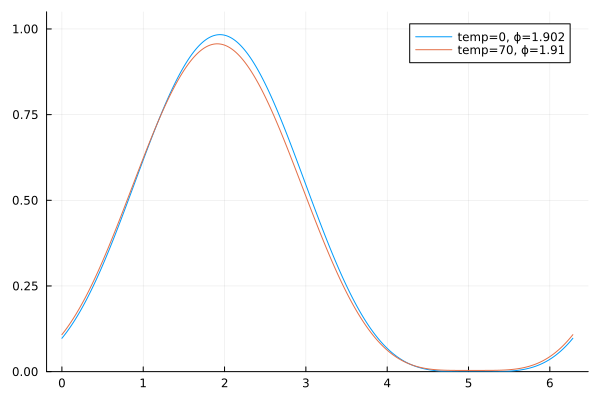

In [15]:
using Plots
ϕ_list = [0.0:0.001:2π;];
F_list = [get_fidelity_with_rz_phi(ρ_loaded, cfg_CZ.ψ0, ϕ) for ϕ in ϕ_list];
plot(ϕ_list0, F_list0, ylims=(0.0,1.05), label = "temp=0, ϕ=$(round(ϕ_cal; digits=3))") #, label = "equal omegas, ϕ = $(ϕ_list_demo[argmax(F_list_demo)])")
plot!(ϕ_list, F_list, label = "temp=70, ϕ=$(round(ϕ_list[argmax(F_list)]; digits=3))") #, label = "equal omegas, ϕ = $(ϕ_list_demo[argmax(F_list_demo)])")

In [16]:
using Printf
println("RZ calibration angle = $(@sprintf("%.4f", ϕ_list[argmax(F_list)]))  with maximum infidelity = $(@sprintf("%.4f", 100*(1-maximum(F_list)))) %")

Run with z_motion

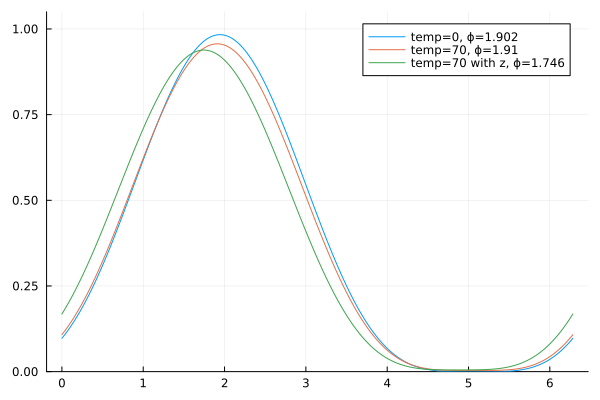

In [17]:
using JLD2
ρ_loaded_z = load_with_JLD2("data\\rho_distributed_z.jld2");
F_list_z = [get_fidelity_with_rz_phi(ρ_loaded_z, cfg_CZ.ψ0, ϕ) for ϕ in ϕ_list]; #, label = "equal omegas, ϕ = $(ϕ_list_demo[argmax(F_list_demo)])")
plot!(ϕ_list, F_list_z, label = "temp=70 with z, ϕ=$(round(ϕ_list[argmax(F_list_z)]; digits=3))") #

In [18]:
maximum(F_list_z)

0.9384017260400854

In [ ]:
#ρ_Φpl

After calibration we can run simulation of CZ parity oscillations experiment

In [21]:
ket_ipos = (ket_0 + 1.0im * ket_1) / sqrt(2)
cfg_CZ.ψ0 = ket_ipos ⊗ ket_ipos;# ρ = simulation_czlp(cfg_CZ)[1][end];

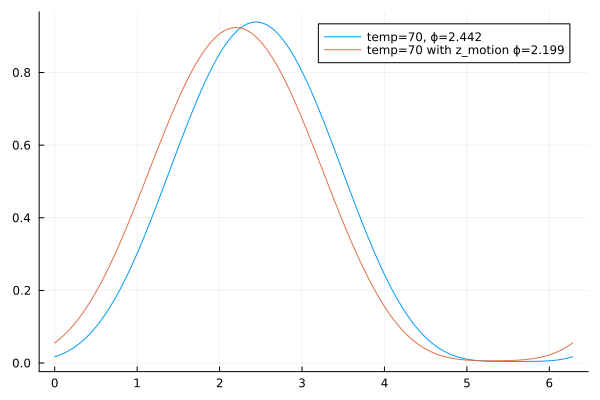

In [ ]:
using JLD2
ρ_loaded = load_with_JLD2("data\\rho_distributed.jld2");
ρ_loaded_z = load_with_JLD2("data\\rho_distributed_z.jld2");

Fid_osc = [get_fidelity_with_rz_phi(ρ_loaded, cfg_CZ.ψ0, ϕ) for ϕ in ϕ_list]; #, label = "equal omegas, ϕ = $(ϕ_list_demo[argmax(F_list_demo)])")
Fid_osc_z = [get_fidelity_with_rz_phi(ρ_loaded_z, cfg_CZ.ψ0, ϕ) for ϕ in ϕ_list]; #, label = "equal omegas, ϕ = $(ϕ_list_demo[argmax(F_list_demo)])")
plot(ϕ_list, Fid_osc, label = "temp=70, ϕ=$(round(ϕ_list[argmax(Fid_osc)]; digits=3))") #
#fidelity = get_fidelity_with_rz_phi(ρ, cfg_CZ.ψ0 , ϕ_cal_0temp)
plot!(ϕ_list, Fid_osc_z, label = "temp=70 with z_motion ϕ=$(round(ϕ_list[argmax(Fid_osc_z)]; digits=3))") #

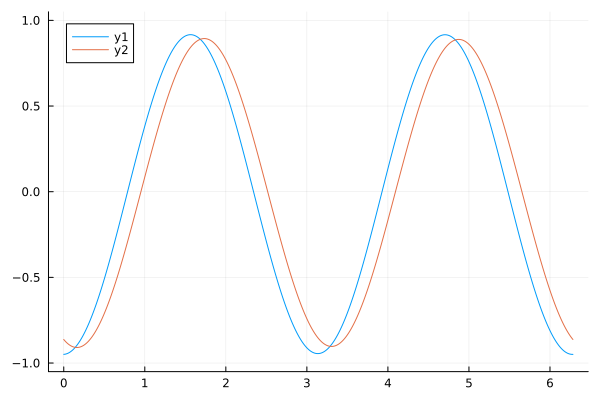

In [29]:
ϕ_ls_0, P_list = get_parity_osc(ρ_loaded, ϕ_cal_0temp) ##ϕ_list, P_list = get_parity_osc(ρ, ϕ_cal) ##θ = cfg_CZ.ϕ_RZ # + ϕ_cal - π
ϕ_ls_0, P_list_z = get_parity_osc(ρ_loaded_z, ϕ_cal_0temp) ##ϕ_list, P_list = get_parity_osc(ρ, ϕ_cal) ##θ = cfg_CZ.ϕ_RZ # + ϕ_cal - π
plot(ϕ_ls_0, P_list, ylims=(-1.05,1.05))  #plot!(ϕ_list0, P_list0)
plot!(ϕ_ls_0, P_list_z)  #plot!(ϕ_list0, P_list0)

Load experimental data and compare

In [30]:
using DataFrames
using CSV
using DelimitedFiles    
df = DataFrame(readdlm("data\\parity_exp_data.dat"), :auto); #df=CSV.File("name.dat";header=true)|>DataFrame

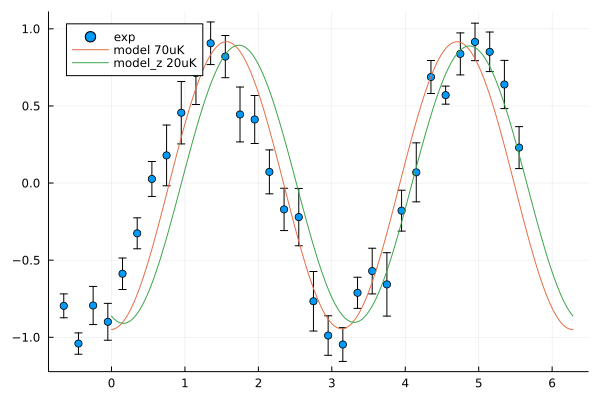

In [33]:
ϕ_ls = df.x1 .- 0.65 
parity = df.x2
errs = df.x3;
scatter(ϕ_ls, parity, yerr = errs, label = "exp")
plot!(ϕ_ls_0, P_list, label = "model 70uK")
plot!(ϕ_ls_0, P_list_z, label = "model_z 20uK")  

Error budget for CZ

In [ ]:
infids, prob = get_cz_error_budget(cfg_CZ; n_samples = 1);

Measuring intermediate state probability...


0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:12<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:12<Inf:Inf, InfGs/it]


Intermediate state probability: 0.947 %
Measuring error from Intermdeiate state decay...


0.0%┣                                                ┫ 0/9 [00:00<00:00, -0s/it]
0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]


Infidelity from Intermdeiate state decay: 0.6768 %
Measuring error from Rydberg state decay...


...

100.0%┣████████████████████████████████████████████┫ 50/50 [08:57<00:00, 11s/it]
100.0%┣████████████████████████████████████████████┫ 50/50 [08:57<00:00, 11s/it]
77.8%┣███████████████████████████████████▊          ┫ 7/9 [46:03<15:21, 461s/it]
0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:11<Inf:Inf, InfGs/it]
4.0%┣█▉                                             ┫ 2/50 [00:22<17:37, 22s/it]
6.0%┣██▉                                            ┫ 3/50 [00:33<12:57, 17s/it]
8.0%┣███▊                                           ┫ 4/50 [00:44<11:17, 15s/it]
10.0%┣████▋                                         ┫ 5/50 [00:55<10:22, 14s/it]
12.0%┣█████▌                                        ┫ 6/50 [01:06<09:44, 13s/it]
14.0%┣██████▍                                       ┫ 7/50 [01:18<09:16, 13s/it]
16.0%┣███████▍                                      ┫ 8/50 [01:29<08:52, 13s/it]
18.0%┣████████▎             

Infidelity from Doppler: 0.0 %
Measuring error from Total...


100.0%┣████████████████████████████████████████████┫ 50/50 [09:14<00:00, 11s/it]
100.0%┣████████████████████████████████████████████┫ 50/50 [09:14<00:00, 11s/it]
88.9%┣████████████████████████████████████████▉     ┫ 8/9 [55:17<07:54, 474s/it]
0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:09<Inf:Inf, InfGs/it]
4.0%┣█▉                                             ┫ 2/50 [00:18<14:09, 18s/it]
6.0%┣██▉                                            ┫ 3/50 [00:27<10:31, 13s/it]
8.0%┣███▊                                           ┫ 4/50 [00:36<09:11, 12s/it]
10.0%┣████▋                                         ┫ 5/50 [00:45<08:31, 11s/it]
12.0%┣█████▌                                        ┫ 6/50 [00:54<07:59, 11s/it]
14.0%┣██████▍                                       ┫ 7/50 [01:03<07:31, 10s/it]
16.0%┣███████▍                                      ┫ 8/50 [01:12<07:12, 10s/it]
18.0%┣████████▎             

Infidelity from Total: 15.9407 %


100.0%┣█████████████████████████████████████████████┫ 50/50 [07:30<00:00, 9s/it]
100.0%┣█████████████████████████████████████████████┫ 50/50 [07:30<00:00, 9s/it]
100.0%┣██████████████████████████████████████████┫ 9/9 [01:02:47<00:00, 471s/it]
100.0%┣██████████████████████████████████████████┫ 9/9 [01:02:47<00:00, 471s/it]


Running modeling in single Jupyter cell for a lot of samples will be slow, for faster calculations you can spread samples across processes and average density matrix in **err_bdgt_distr.jl** file, which saves it in **err_bdgt.jld2** file that you can read using JLD2

In [5]:
using NeutralAtoms
infidelities = load_with_JLD2("data\\err_bdgt.jld2")

Dict{Any, Any} with 8 entries:
  "Doppler"                  => 0.124677
  "Total"                    => 0.246534
  "blockade"                 => 0.104948
  "z_motion"                 => 0.0676684
  "Intermediate probability" => 0.00955813
  "Rydberg state decay"      => 0.0115348
  "xy_motion"                => 0.0290003
  "Intermediate state decay" => 0.0423537

In [8]:
using Plots
function plot_cz_infidelity(infidelities;
    dir_name="data\\", 
    file_name="plot_cz.png",
    title="Error budget for Phi+ after CZ")

    keys_iF   = collect(keys(infidelities))
    keys_ordered = ["Total","Laser noise","Atom motion","blockade","z_motion","xy_motion","xyz_motion","Doppler", "Intermediate probability","Intermediate state decay","Rydberg state decay"]
    #keys_ordered = ["Общее", "Шум лазера","Движение атома","Движение по Z","Движение в XY","xyz_motion","Doppler", "Вероятность |p>","Распад |p>","Распад |r>"]
    
    keys_final = [key for key in keys_ordered if key in keys_iF]
    values_final = [(key=="Intermediate probability") ? 100 * infidelities[key] : 100*(infidelities[key]-infidelities["Intermediate probability"])
    for key in keys_ordered if key in keys_iF]
    # values_final = [(key=="Вероятность |p>") ? 100 * infidelities[key] : 
    #100*(infidelities[key]-infidelities["Вероятность |p>"]) for key in keys_ordered if key in keys_iF]

    p = bar(keys_final, values_final;
    xrotation=45,     margin=10Plots.mm,
    ylabel="Ошибка приготовления |Ф+>, %",      title=title,
    label=nothing,    dpi=300,    size=(600, 600),
    xguidefontsize = 14,    yguidefontsize = 14,
    xtickfontsize = 14,    ytickfontsize = 14,
    color=RGBA(135.0/255,203.0/255,230.0/255,1.0))

    savefig("$(dir_name)$(file_name)")
    display(p)

    return keys_final, values_final
end;

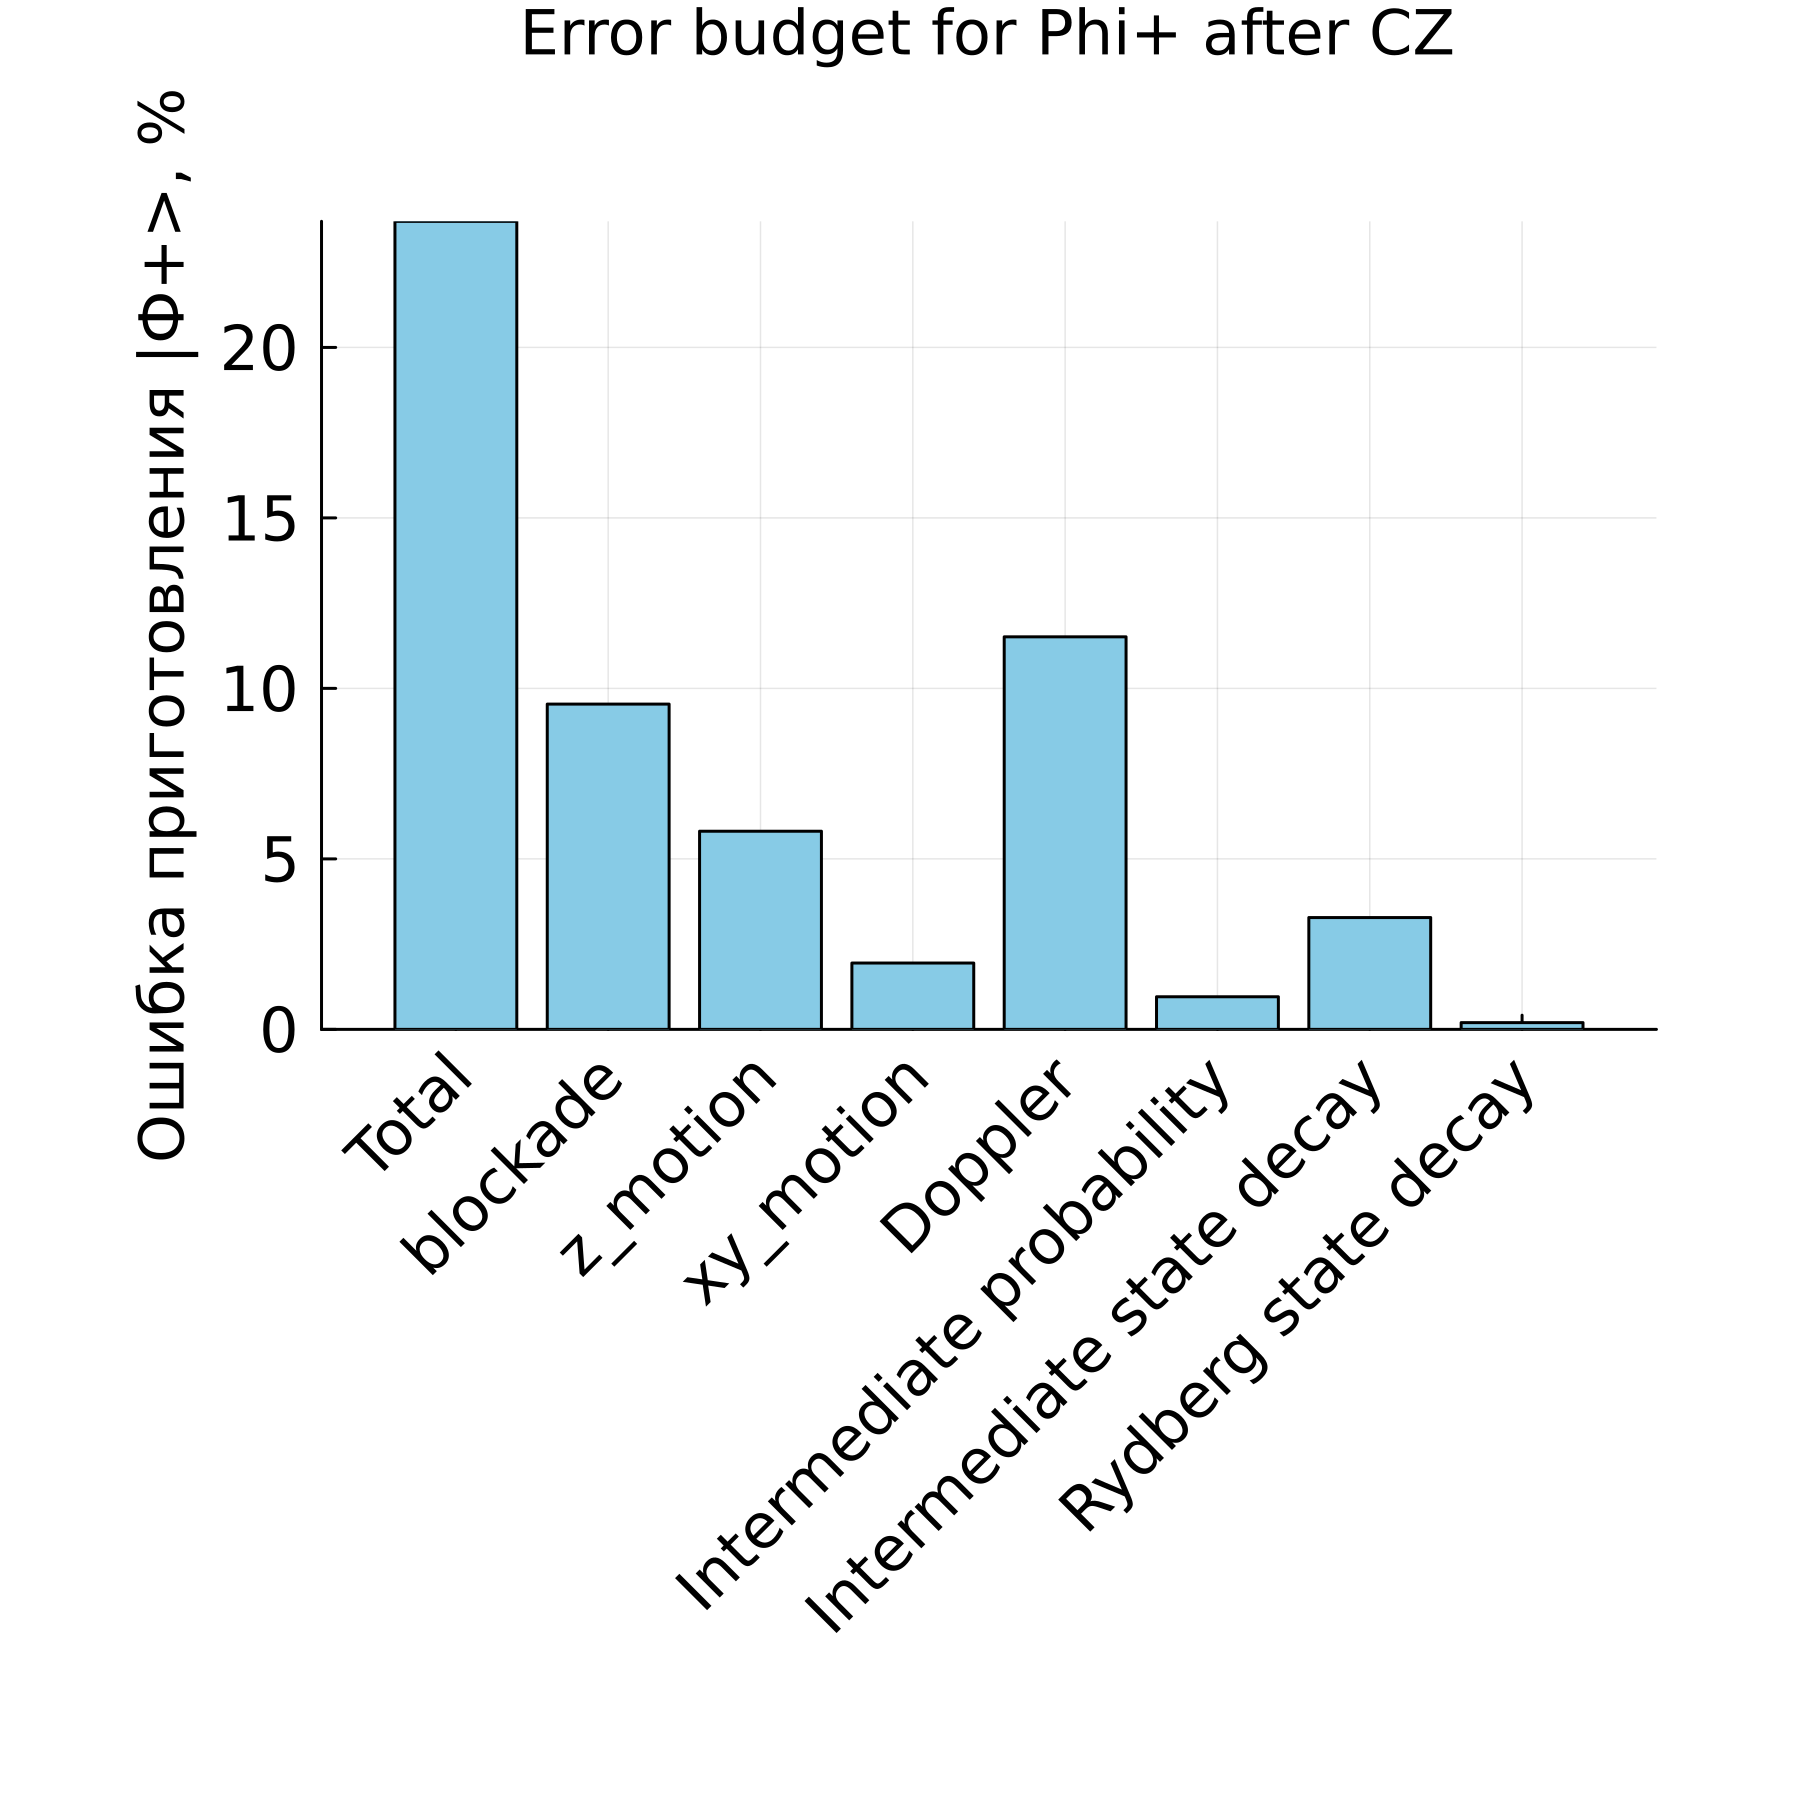

(["Total", "blockade", "z_motion", "xy_motion", "Doppler", "Intermediate probability", "Intermediate state decay", "Rydberg state decay"], [23.697570127400837, 9.539009558186695, 5.811030787740634, 1.9442182791710394, 11.511895360453794, 0.9558133897152654, 3.2795545074651766, 0.1976665807674638])

In [9]:
plot_cz_infidelity(infidelities)

In [ ]:
infid1 = infidelities
infs = Dict("Общее" =>  0.0760417,
"Движение в XY" => 0.023481,
"Движение по Z" => 0.035843,
"Вероятность |p>" => 0.0042587,
"Распад |p>" => 0.00683872,
"Распад |r>" => 0.00474846);

5P excitation in flattop field

Load default config for 5P and c_xy coeficients from field decomposition, derived in flattop notebook and saved to config

In [44]:
using NeutralAtoms
include("../conf/default.jl")
_, cfg_CZ = get_default_configs();
c_xy = get_default_cxy(); #c_xy = get_ideal_cxy();

In [45]:
cfg_CZ.n_samples = 1;
cfg_CZ.atom_params[2] = 0.1; #
cfg_CZ.second_laser_params["type"] = "flattop_HG" #"gauss" #
cfg_CZ.second_laser_params["coeffs_xy"] = c_xy; 
cfg_CZ.second_laser_params

Dict{String, Any} with 7 entries:
  "coeffs_xy" => [1.19061 -0.00432629 … -3.30497e-14 -2.58291e-15; 0.013834 0.0…
  "z0"        => 26.4555
  "n_sg"      => 1
  "θ"         => 0.0
  "w0"        => 2.0
  "Ω"         => 285.298
  "type"      => "flattop_HG"

Create list of basis states and projectors to obtain truth table of CNOT gate, example modeling for low temperature and 1 sample

In [47]:
using Plots
ϕ_l, F_l, ϕ_cal = CZ_calibration_by_fidelity_oscillation(cfg_CZ);
println(ϕ_cal, " ", 1-maximum(F_l))
plot(ϕ_l, F_l);

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:30<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:30<Inf:Inf, InfGs/it]


2.164 0.04888684199714399


In [48]:
Id = ket_0 ⊗ dagger(ket_0) + ket_1 ⊗ dagger(ket_1) + ket_p ⊗ dagger(ket_p) + ket_r ⊗ dagger(ket_r) + ket_l ⊗ dagger(ket_l);
Had = Id ⊗ (ket_0 ⊗ dagger(ket_0) - ket_1 ⊗ dagger(ket_1) + ket_0 ⊗ dagger(ket_1) + ket_1 ⊗ dagger(ket_0))/sqrt(2)
RZ = θ -> (exp(-1.0im*θ/2)*(ket_0 ⊗ dagger(ket_0)) +  exp(1.0im*θ/2)*(ket_1 ⊗ dagger(ket_1)));
ϕ = ϕ_cal #ϕ_cal_0temp
glrz = RZ(ϕ) ⊗ RZ(ϕ);
#ket_pos = (ket_0 + ket_1) / sqrt(2) # ket_neg = (ket_0 - ket_1) / sqrt(2)pr_m = ket_neg ⊗ dagger(ket_neg) #pr_p = ket_pos ⊗ dagger(ket_pos); 
pr_0 = ket_0 ⊗ dagger(ket_0)
pr_1 = ket_1 ⊗ dagger(ket_1);
projs = [pr_0 ⊗ pr_0, pr_0 ⊗ pr_1, pr_1 ⊗ pr_0, pr_1 ⊗ pr_1]; #projs = [pr_p ⊗ pr_p, pr_p ⊗ pr_m, pr_m ⊗ pr_p, pr_m ⊗ pr_m];
states = [ket_0 ⊗ ket_0, ket_0 ⊗ ket_1, ket_1 ⊗ ket_0, ket_1 ⊗ ket_1];

In [49]:
for state in states 
    cfg_CZ.ψ0 = Had * state #(ket_1 ⊗ ket_pos
    ρ_end = simulation_czlp(cfg_CZ)[1][end] ; #_rec2d
    ρ = Had*glrz * ρ_end * dagger(Had*glrz);
    pr_s = [round(real(expect(proj, ρ)); digits=6) for proj in projs] 
    println(pr_s)
end

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:30<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:30<Inf:Inf, InfGs/it]


[0.979038, 0.00541, 0.0, 0.0]


0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]


[0.005115, 0.979349, 0.0, 0.0]


100.0%┣██████████████████████████████████████████┫ 1/1 [00:27<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:27<Inf:Inf, InfGs/it]
0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]


[0.005538, 0.004834, 0.007982, 0.926293]


100.0%┣██████████████████████████████████████████┫ 1/1 [00:41<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:41<Inf:Inf, InfGs/it]
0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]


[0.004895, 0.005475, 0.924962, 0.008864]


100.0%┣██████████████████████████████████████████┫ 1/1 [00:30<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:30<Inf:Inf, InfGs/it]


2 gauss modeling and comparison with flattop beam

In [66]:
include("../conf/default.jl")
cfg_CZ_2gauss = get_default_cfg2gauss(2.0);
cfg_CZ_2gauss.second_laser_params

Dict{String, Any} with 12 entries:
  "z1"            => 26.4555
  "w1"            => 2.0
  "beams_centers" => [[0.0, 1.7, 0.0], [0.0, -1.7, 0.0]]
  "rel_phase"     => 0.0
  "n_sg"          => 1
  "z"             => 26.4555
  "Ω1"            => 270.277
  "z0"            => 26.4555
  "θ"             => 0.0
  "w0"            => 2.0
  "Ω"             => 270.277
  "type"          => "2gauss"

In [67]:
ws = vcat(1.3:0.1:1.7) ;#, 2.6:0.2:3.2)

In [ ]:
plot([0.0],[0.0], ylims=(0.0,1.05));

In [69]:
Fids = []
for w in ws
    cfg_CZ_2gauss = get_default_cfg2gauss(w);
    cfg_CZ_2gauss.n_samples = 20
    #cfg_CZ_2gauss.atom_params[2] = 0.1
    ϕ_list, F_list, ϕ_ = CZ_calibration_by_fidelity_oscillation(cfg_CZ_2gauss)     #ρ_2gauss, _ = simulation_czlp(cfg_CZ_2gauss)[1][end] ; 

    println(w , " ", maximum(F_list))
    push!(Fids, maximum(F_list))
    plot!(ϕ_list, F_list, label = "$w") 
end;

0.0%┣                                               ┫ 0/20 [00:00<00:00, -0s/it]
5.0%┣██▏                                        ┫ 1/20 [00:28<Inf:Inf, InfGs/it]
10.0%┣████▋                                         ┫ 2/20 [00:55<16:23, 55s/it]
15.0%┣███████                                       ┫ 3/20 [01:20<11:23, 40s/it]
20.0%┣█████████▏                                    ┫ 4/20 [01:48<09:37, 36s/it]
25.0%┣███████████▌                                  ┫ 5/20 [02:15<08:25, 34s/it]
30.0%┣█████████████▉                                ┫ 6/20 [02:41<07:31, 32s/it]
35.0%┣████████████████                              ┫ 7/20 [03:08<06:47, 31s/it]
40.0%┣██████████████████▍                           ┫ 8/20 [03:34<06:08, 31s/it]
45.0%┣████████████████████▊                         ┫ 9/20 [04:01<05:32, 30s/it]
50.0%┣██████████████████████▌                      ┫ 10/20 [04:28<04:58, 30s/it]
55.0%┣████████████████████████▊                    ┫ 11/20 [04:55<04:25, 29s/it]
60.0%┣██████████████████████

1.3 0.9456617984081178


0.0%┣                                               ┫ 0/20 [00:00<00:00, -0s/it]
5.0%┣██▏                                        ┫ 1/20 [00:27<Inf:Inf, InfGs/it]
10.0%┣████▋                                         ┫ 2/20 [00:53<15:46, 53s/it]
15.0%┣███████                                       ┫ 3/20 [01:18<11:06, 39s/it]
20.0%┣█████████▏                                    ┫ 4/20 [01:43<09:10, 34s/it]
25.0%┣███████████▌                                  ┫ 5/20 [02:08<08:00, 32s/it]
30.0%┣█████████████▉                                ┫ 6/20 [02:33<07:10, 31s/it]
35.0%┣████████████████                              ┫ 7/20 [03:00<06:29, 30s/it]
40.0%┣██████████████████▍                           ┫ 8/20 [03:27<05:55, 30s/it]
45.0%┣████████████████████▊                         ┫ 9/20 [03:54<05:21, 29s/it]
50.0%┣██████████████████████▌                      ┫ 10/20 [04:19<04:48, 29s/it]
55.0%┣████████████████████████▊                    ┫ 11/20 [04:44<04:16, 28s/it]
60.0%┣██████████████████████

1.4 0.9372593428409843


0.0%┣                                               ┫ 0/20 [00:00<00:00, -0s/it]
5.0%┣██▏                                        ┫ 1/20 [00:25<Inf:Inf, InfGs/it]
10.0%┣████▋                                         ┫ 2/20 [00:51<15:13, 51s/it]
15.0%┣███████                                       ┫ 3/20 [01:16<10:46, 38s/it]
20.0%┣█████████▏                                    ┫ 4/20 [01:41<08:58, 34s/it]
25.0%┣███████████▌                                  ┫ 5/20 [02:06<07:52, 31s/it]
30.0%┣█████████████▉                                ┫ 6/20 [02:31<07:03, 30s/it]
35.0%┣████████████████                              ┫ 7/20 [02:56<06:22, 29s/it]
40.0%┣██████████████████▍                           ┫ 8/20 [03:22<05:46, 29s/it]
45.0%┣████████████████████▊                         ┫ 9/20 [03:46<05:11, 28s/it]
50.0%┣██████████████████████▌                      ┫ 10/20 [04:11<04:39, 28s/it]
55.0%┣████████████████████████▊                    ┫ 11/20 [04:36<04:08, 28s/it]
60.0%┣██████████████████████

1.5 0.9331186518214389


0.0%┣                                               ┫ 0/20 [00:00<00:00, -0s/it]
5.0%┣██▏                                        ┫ 1/20 [00:27<Inf:Inf, InfGs/it]
10.0%┣████▋                                         ┫ 2/20 [00:52<15:43, 52s/it]
15.0%┣███████                                       ┫ 3/20 [01:18<11:07, 39s/it]
20.0%┣█████████▏                                    ┫ 4/20 [01:44<09:16, 35s/it]
25.0%┣███████████▌                                  ┫ 5/20 [02:11<08:11, 33s/it]
30.0%┣█████████████▉                                ┫ 6/20 [02:38<07:21, 32s/it]
35.0%┣████████████████                              ┫ 7/20 [03:03<06:36, 30s/it]
40.0%┣██████████████████▍                           ┫ 8/20 [03:28<05:57, 30s/it]
45.0%┣████████████████████▊                         ┫ 9/20 [03:53<05:21, 29s/it]
50.0%┣██████████████████████▌                      ┫ 10/20 [04:20<04:49, 29s/it]
55.0%┣████████████████████████▊                    ┫ 11/20 [04:46<04:18, 29s/it]
60.0%┣██████████████████████

1.6 0.9406190470365954


0.0%┣                                               ┫ 0/20 [00:00<00:00, -0s/it]
5.0%┣██▏                                        ┫ 1/20 [00:25<Inf:Inf, InfGs/it]
10.0%┣████▋                                         ┫ 2/20 [00:49<14:33, 49s/it]
15.0%┣███████                                       ┫ 3/20 [01:13<10:18, 36s/it]
20.0%┣█████████▏                                    ┫ 4/20 [01:37<08:38, 32s/it]
25.0%┣███████████▌                                  ┫ 5/20 [02:02<07:36, 30s/it]
30.0%┣█████████████▉                                ┫ 6/20 [02:26<06:49, 29s/it]
35.0%┣████████████████                              ┫ 7/20 [02:51<06:11, 29s/it]
40.0%┣██████████████████▍                           ┫ 8/20 [03:15<05:35, 28s/it]
45.0%┣████████████████████▊                         ┫ 9/20 [03:39<05:01, 27s/it]
50.0%┣██████████████████████▌                      ┫ 10/20 [04:04<04:31, 27s/it]
55.0%┣████████████████████████▊                    ┫ 11/20 [04:28<04:01, 27s/it]
60.0%┣██████████████████████

1.7 0.9675160338209563


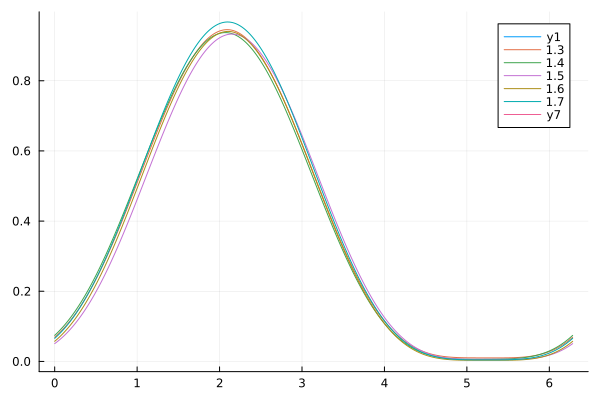

In [70]:
plot!([0.0],[0.0])

In [24]:
"""
data = DataFrame(    Column1 = cfg.tspan,    Column2 = Pr_HG)
CSV.write("output.csv", data)
plot(cfg.tspan, Pr_HG) """  

"data = DataFrame(    Column1 = cfg.tspan,    Column2 = Pr_HG)\nCSV.write(\"output.csv\", data)\nplot(cfg.tspan, Pr_HG) "

In [ ]:
include("../conf/configs_gen.jl")
_, cfg_CZ = get_6P_config(); 
cfg_CZ.atom_params[2] = 70.1;  #cfg_CZ.error_options 
cfg_CZ.error_options["atom_motion"] = false
cfg_CZ.error_options["xy_motion"] = false
cfg_CZ.error_options["z_motion"] = false
cfg_CZ.error_options["Doppler"] = false
cfg_CZ.error_options["spontaneous_decay_intermediate"]    = false
cfg_CZ.error_options["spontaneous_decay_rydberg"]         = false
cfg_CZ.error_options["laser_noise"]                       = false
cfg_CZ.n_samples                         = 100;

include("../conf/configs_gen.jl")
_, cfg_CZ = get_6P_config(); 
cfg_CZ.atom_params[2] = 100.1;
cfg_CZ.n_samples                         = 50;

phi_list, F_list, ϕ_RZ = CZ_calibration_by_fidelity_oscillation(cfg_CZ);
println(ϕ_RZ)
calibration_error = 1.0 - maximum(F_list)


ket_pos = (ket_0 + ket_1) / sqrt(2)
Φp = (ket_0 ⊗ ket_0 + ket_1 ⊗ ket_1)/sqrt(2);
Had = Id ⊗ Hadamard

cfg_t = deepcopy(cfg)

println("Measuring intermediate state probability...")
global_RZ = RZ(ϕ_RZ) ⊗ RZ(ϕ_RZ);

calibration_error = 1.0 - maximum(F_list) #real(dagger(Φp) * ρ_real * Φp)

println("Intermediate state probability: $(round(100.0*calibration_error; digits=4)) %")

for name in ProgressBar(names)
    cfg_t = deepcopy(configs[name])
    println("Measuring error from $(name)...")

    cfg_t.ψ0 = ket_pos ⊗ ket_pos
    ρ_real .= Had * global_RZ * ρ_real * dagger(Had * global_RZ)
    infidelities[name] = maximum([(1.0 - real(dagger(Φp) * ρ_real * Φp) - calibration_error), 0.0])
    #infidelities[name] = 1.0 - maximum(CZ_calibration_by_fidelity_oscillation(cfg_t)[2]);
